In [70]:
import sklearn.datasets as sk
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.preprocessing import StandardScaler

wine = sk.load_wine()
X = wine.data
y = wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state=43)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)
accuracy, y_pred, y_test

(0.9629629629629629,
 array([2, 1, 0, 0, 1, 1, 2, 0, 1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 2, 0, 0,
        0, 0, 2, 0, 2, 1, 0, 1, 0, 1, 2, 0, 0, 1, 0, 0, 0, 2, 2, 0, 0, 2,
        1, 2, 2, 1, 2, 0, 2, 0, 2, 2]),
 array([2, 1, 0, 0, 1, 1, 2, 0, 1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 2, 0, 0,
        0, 0, 2, 0, 2, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 0, 0, 2, 2, 0, 0, 2,
        1, 2, 2, 1, 2, 1, 2, 0, 2, 2]))

In [71]:
from sklearn.decomposition import PCA

pca = PCA(2)
X_pca_train = pca.fit_transform(X_train)
X_pca_test = pca.transform(X_test)

knn.fit(X_pca_train, y_train)
accuracy_pca = knn.score(X_pca_test, y_test)
accuracy_pca

0.9259259259259259

In [72]:
from sklearn.metrics import accuracy_score

alcohol_idx = list(wine.feature_names).index("alcohol")
y_rule = np.where(X_test[:, alcohol_idx] < 12, 0, np.where(X_test[:, alcohol_idx] < 13, 1, 2))

rule_acc = accuracy_score(y_test, y_rule)
rule_acc

0.37037037037037035

In [73]:
cov = np.cov(X_train.T)
inv_cov = np.linalg.inv(cov)

metrics = {
    "euclidean": {"metric": "euclidean"},
    "manhattan": {"metric": "manhattan"},
    "cosine": {"metric": "cosine"},
    "chebyshev": {"metric": "chebyshev"},
    "mahalanobis": {"metric": "mahalanobis", "metric_params": {"VI": inv_cov}}
}

results = {}

for name, params in metrics.items():

    knn = KNeighborsClassifier(n_neighbors=3, **params)

    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

results

{'euclidean': 0.9629629629629629,
 'manhattan': 0.9444444444444444,
 'cosine': 0.9444444444444444,
 'chebyshev': 0.9074074074074074,
 'mahalanobis': 0.8888888888888888}

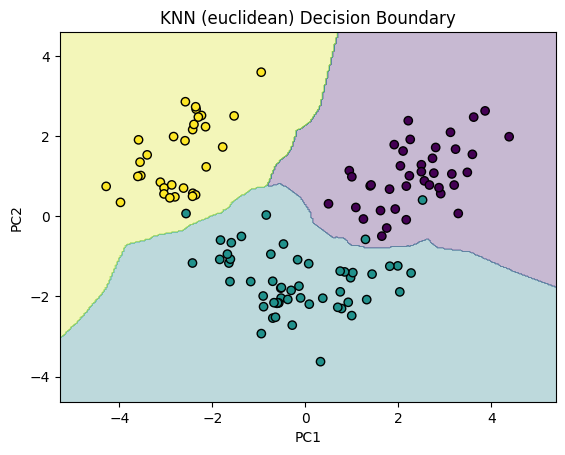

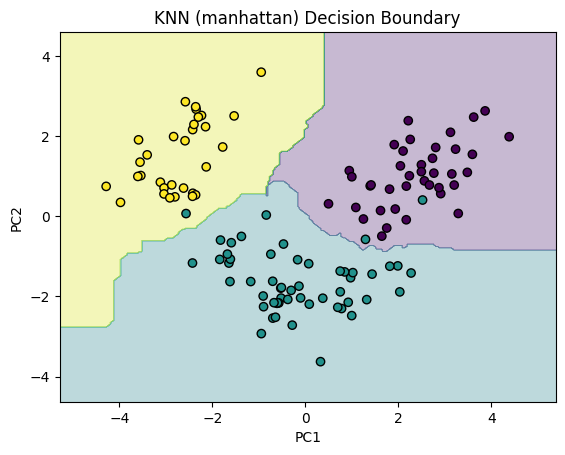

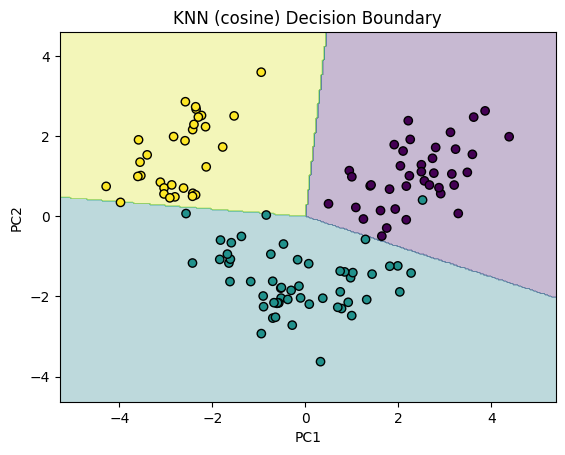

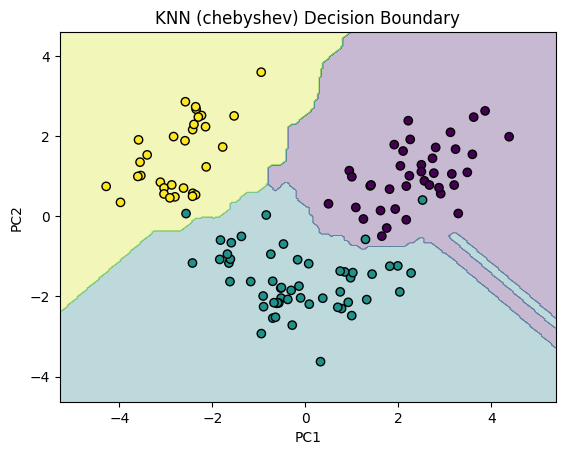

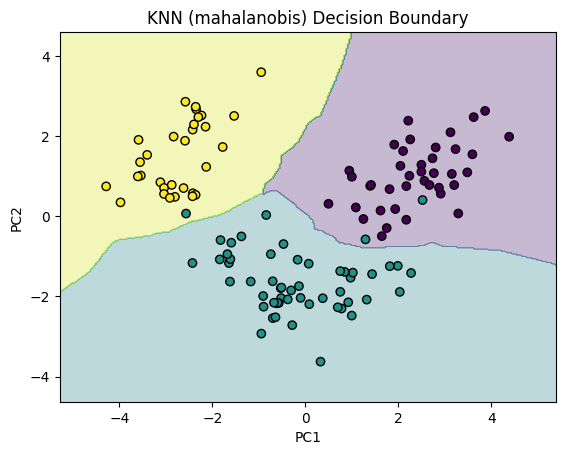

In [81]:
import matplotlib.pyplot as plt

cov = np.cov(X_pca_train.T)
inv_cov = np.linalg.inv(cov)

metrics = {
    "euclidean": {"metric": "euclidean"},
    "manhattan": {"metric": "manhattan"},
    "cosine": {"metric": "cosine"},
    "chebyshev": {"metric": "chebyshev"},
    "mahalanobis": {"metric": "mahalanobis", "metric_params": {"VI": inv_cov}}
}

for name, params in metrics.items():
    knn = KNeighborsClassifier(n_neighbors=3, **params)
    knn.fit(X_pca_train, y_train)
    x_min, x_max = X_pca_train[:,0].min()-1, X_pca_train[:,0].max()+1
    y_min, y_max = X_pca_train[:,1].min()-1, X_pca_train[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # plt.subplot(2,3,i+1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    plt.scatter(X_pca_train[:,0], X_pca_train[:,1], c=y_train, cmap="viridis", edgecolor="k")
    plt.title(f"KNN ({name}) Decision Boundary")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [76]:
from sklearn.linear_model import LinearRegression

y_train_soft = y_train * 0.5

lr = LinearRegression()
lr.fit(X_train, y_train_soft)

y_pred_lr = lr.predict(X_test)

y_pred_class = np.where(y_pred_lr < 0.25, 0, np.where(y_pred_lr < 0.75, 1, 2))

acc = accuracy_score(y_test, y_pred_class)
acc

0.9074074074074074

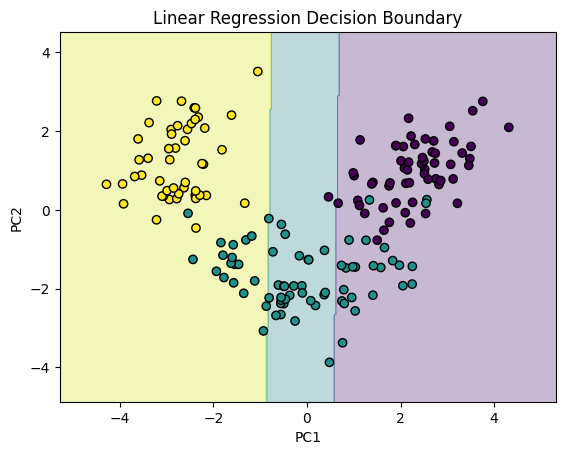

In [80]:
X_pca = pca.fit_transform(scaler.fit_transform(X))
y_soft = y * 0.5
lr.fit(scaler.fit_transform(X_pca), y_soft)

x_min, x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1
y_min, y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

pred_lr_pca = lr.predict(grid)

pred_class = np.array(np.where(pred_lr_pca < 0.25, 0, np.where(pred_lr_pca < 0.75, 1, 2)))
pred_class = pred_class.reshape(xx.shape)

plt.contourf(xx, yy, pred_class, alpha=0.3, cmap="viridis")
plt.scatter(X_pca[:,0], X_pca[:,1], c=wine.target, cmap="viridis", edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Linear Regression Decision Boundary")
plt.show()
